# 3. Siltuma vadīšana

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

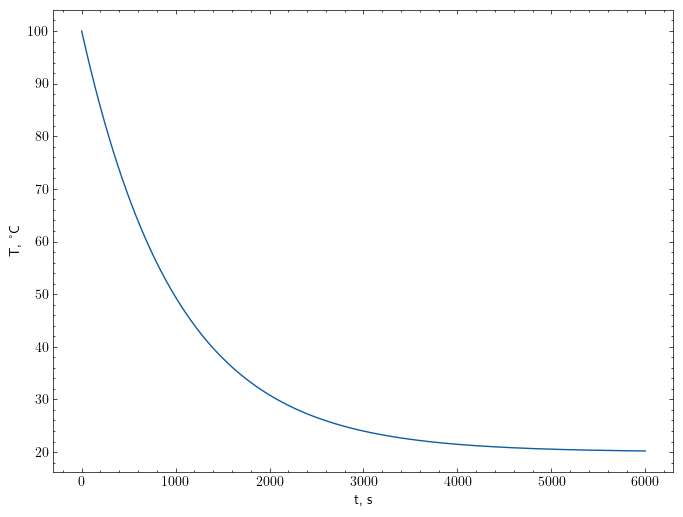

In [3]:
T_gaiss = 20
T_init = 100
k = 1e-3

def T_analytical(t):
    return T_gaiss + (T_init - T_gaiss) * np.exp(-k * t)

t_anal = np.linspace(0, 6000, 1000)
with plt.style.context('science'):
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.plot(t_anal, T_analytical(t_anal))
    plt.xlabel("t, s")
    plt.ylabel("T, °C")
    plt.savefig("siltumvadisana.png", dpi=300)
with plt.style.context('notebook'):
    plt.show()

## Pen and paper daļa no lekcijas

Mūsu uzdevums ir pāriet no $\frac{dT}{dt} = -\kappa (T - T_g)$, kur aplūkojām punktveida objektu, uz telpisku reprezentāciju. Lai to izdarītu, pielietosim trīs idejas:
1. Termiskās enerģijas blīvumu $e = \rho c_p u$, kur $\rho$ ir blīvums, $c_p$ ir īpatnēja siltumietilpība un $u$ ir temperatūra.
2. Furjē likumu $\mathbf{q} = -\lambda \nabla u$, kur $\mathbf{q}$ ir siltuma plūsmas blīvums un $\lambda$ ir siltumvadītspēja. Jeb $\frac{dQ}{dt} = -k \frac{dT}{dx}S$, kur $S$ ir šķērsgriezuma laukums.
3. Enerģijas saglabāšanas likumu $\frac{dE}{dt} = \dot{Q}$, kur $E$ ir enerģija un $\dot{Q}$ ir siltuma plūsma.

Cik enerģijas ir tilpumā $\omega$, tik ienāk/iznāk caur tilpuma robežu $\partial \omega$:
$$\frac{d}{dt} \int_\omega e \, dV = - \int_{\partial \omega} \mathbf{q} \cdot \mathbf{n} \, dS $$
Pielietojot Diverģences teorēmu, varam pārrakstīt labās puses integrāli kā tilpuma integrāli:
$$\frac{d}{dt} \int_\omega e \, dV = - \int_\omega \nabla \cdot \mathbf{q} \, dV $$
Tā kā šis ir spēkā jebkuram tilpumam $\omega$, varam vienkāršot līdz:
$$\frac{\partial e}{\partial t} = - \nabla \cdot \mathbf{q}$$
Pielietojot Furjē likumu, iegūstam:
$$\frac{\partial e}{\partial t} = \nabla \cdot (k \nabla u)$$
Ja $e = \rho c_p u$, tad:
$$\rho c_p \frac{\partial u}{\partial t} = \nabla \cdot (k \nabla u)$$
Ja $k, \rho, c_p$ ir const, iegūstam:
$$\frac{\partial u}{\partial t} = \kappa \nabla^2 u,$$
kuru sauc par siltuma vadīšanas vienādojumu.
Bet, vienkāršosim sev dzīvi un aplūkosim tikai vienu dimensiju, t.i. $x$ asi:
$$\frac{\partial u}{\partial t} = \kappa \frac{\partial^2 u}{\partial x^2}.$$

Šim vienādojumam nav fiziskās jēgas bez sākuma un robežnosacījumiem. Sākuma nosacījums varētu būt, piemēram, $u(x, 0) = f(x)$, kur $f(x)$ ir sākotnējā temperatūras sadalījuma funkcija. Robežnosacījumi varētu būt, piemēram, $u(0, t) = T_0$ un $u(L, t) = T_L$, kur $T_0$ un $T_L$ ir temperatūras vērtības pie $x=0$ un $x=L$.

Kopumā sistēma izskatās šādi:
$$\begin{cases}
\frac{\partial u}{\partial t} = \kappa \frac{\partial^2 u}{\partial x^2}, & 0 < x < L, t > 0 \\
u(x, 0) = f(x), & 0 \leq x \leq L \\
u(0, t) = T_0, & t \geq 0 \\
u(L, t) = T_L, & t \geq 0
\end{cases}$$

Gribam atrisināt izmantojot Eilera metodi. Diskretizēsim laiku un telpu:
$$t_n = n \Delta t, \quad x_j = j \Delta x$$
Un atvasinājumus aizstāj ar diferencēm:
$$\frac{u_j^{n+1} - u_j^n}{\Delta t} = \kappa \frac{u_{j+1}^n - 2u_j^n + u_{j-1}^n}{\Delta x^2}$$
No šejienes varam izteikt $u_j^{n+1}$:
$$u_j^{n+1} = u_j^n + \frac{\kappa \Delta t}{\Delta x^2} (u_{j+1}^n - 2u_j^n + u_{j-1}^n)$$
Definējot $r = \frac{\kappa \Delta t}{\Delta x^2}$, iegūstam:
$$u_j^{n+1} = u_j^n + r (u_{j+1}^n - 2u_j^n + u_{j-1}^n)$$
Šī ir Eilera metode siltuma vadīšanas vienādojumam.


## Stabilitāte

Iedvesmojoties $\frac{dT}{dt} = -k (T - T_g)$ analītiskajam atrisinājumam $T(t) = T_g + (T_0 - T_g)e^{-kt}$, kas pēc būtības ir eksponenciālā dilšana. Tāpēc, pieņemsism, ka atrisinājums ir eksponenciāls, t.i., $u(x, t_n) = e^{i k x}$, un ievietojot to diferencēšanas vienādojumā, mēs iegūstam:

$$
u^{n+1}_{j} = e^{i k j \Delta x} + r e^{i k j \Delta x (j + 1)} - 2 e^{i k j \Delta x} + e^{i k j \Delta x (j - 1)} = e^{i k j \Delta x} (1 + r (e^{i k \Delta x} - 2 + r e^{-i k \Delta x})) = A e^{i k j \Delta x},
$$

kur $A$ ir amplifikācijas faktors. Lai metode būtu stabila, mums ir jānodrošina, ka $|A| \leq 1$ visiem $k$.
$A(\theta) = 1 - 2r (1 - \cos(\theta \Delta x))$.

Eilera metode ir stabila, ja $|A| \leq 1$ visiem $\theta$. Sliktākais gadījums ir, kad $\cos(\theta \Delta x) = -1$, kas dod $A = 1 - 4r$. Tāpēc, lai nodrošinātu stabilitāti, mums ir jānodrošina, ka $|1 - 4r| \leq 1$, kas noved pie nosacījuma $0 \leq r \leq \frac{1}{2}$. Jeb 

$$
0 \leq r \leq \frac{1}{2}
$$

jeb

$$
\frac{\kappa \Delta t}{\Delta x^2} \leq \frac{1}{2}
$$

ir stabilitātes kritērijs Eilera metodei siltuma vadīšanas vienādojumam.

### Piemērs 1.1

Pseido-kods, lai aproksimētu $u(t,x)$

$$
\begin{cases}
u_t = u_{xx} & \text{on } 0 \le x \le 1 \quad \text{for } t \in [0,T], \\
u(t,0) = u(t,1) = 0 & \text{for } t \ge 0, \\
u(0,x) = f(x)
\end{cases}
\tag{*}
$$

ar $\Delta x = 1/N$ un $\Delta t = T/M$.

- definē sākuma un robežnosacījumus, $t_b$

- diskretizē telpu un laiku:

  $$
  x = \mathrm{linspace}(0,1,N+1)
  \qquad
  u = \mathrm{zeros}(N+1, M+1)
  $$

  $$
  t = \mathrm{linspace}(0,T,M+1)
  $$

- implementē robežnosacījumus:

  $$
  u(:,1) = 0
  $$

  $$
  u(:,N+1) = 0
  $$

  $$
  (u(t,0)=0,\quad u(t,1)=0)
  $$

- implementē sākuma nosacījumu:

  $$
  u(1,:) = f(x(:))
  \qquad
  (u(0,x)=f(x))
  $$

- definē $r$:

  $$
  r = \kappa \frac{\Delta t}{(\Delta x)^2}
  $$

```text
for n = 2 : N
    for j = 2 : M
        u(n,j) = r*u(n-1,j-1) + (1-2r)*u(n-1,j) + r*u(n-1,j+1)
    end
end